# Домашнее задание к семинару 14 (HW14)
Тема: эмбеддинги, индекс FAISS, оценка качества retrieval, обновление базы знаний и базовый mini-RAG.

## Импорты, seed и среда

In [1]:
# Базовые библиотеки для воспроизводимости, анализа и удобного вывода результатов.
import os
import re
import sys
import random
import subprocess
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.feature_extraction.text import TfidfVectorizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"


def safe_ensure_package(package_name: str, import_name: Optional[str] = None) -> bool:
    """Пытается импортировать пакет и при необходимости установить его через pip.
    Если установка не удалась, возвращает False, но не роняет ноутбук.
    """
    target = import_name or package_name
    try:
        __import__(target)
        return True
    except Exception:
        print(f"Пробуем установить пакет: {package_name}")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
            __import__(target)
            return True
        except Exception as e:
            print(f"Не удалось подготовить пакет {package_name}: {e!r}")
            return False


FAISS_READY = safe_ensure_package("faiss-cpu", "faiss")

try:
    import faiss  # type: ignore
except Exception:
    faiss = None
    FAISS_READY = False


# sentence-transformers опционален: ноутбук умеет работать и без него.
SENTENCE_TRANSFORMERS_READY = safe_ensure_package("sentence-transformers", "sentence_transformers")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("FAISS доступен:", FAISS_READY)
print("sentence-transformers доступен:", SENTENCE_TRANSFORMERS_READY)

Пробуем установить пакет: faiss-cpu
Пробуем установить пакет: sentence-transformers


C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NumPy: 2.2.6
Pandas: 2.3.3
FAISS доступен: True
sentence-transformers доступен: True


In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)


set_seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

print("Устройство для работы:", DEVICE)

Устройство для работы: cpu


In [6]:
ARTIFACTS_DIR = "./artifacts/"

## База знаний и первичный анализ
Это csv файл с документами на тему банковского обслуживания, кредитования и так далее. В документах предоставлена подробная информация для клиентов и сотрудников банка о сервисах, услугах, условиях и продуктах банка. По ней разумно строить RAG систему, так как информация достаточно подробная и при этом лаконичная, есть несколько тем и подтем, которые могут пересекаться.

In [5]:
df = pd.read_csv("C:/Users/Admin/Downloads/train_data.csv")

In [7]:
df.head()

,id,annotation,tags,text
0,doc_001,Светлана из Казани дает частные уроки английск...,"['Начать бизнес', 'Самозанятые', 'Свое дело', ...",## Кто такой самозанятый?\n\nПо закону самозан...
1,doc_002,"Елене назначили социальное пособие на ребенка,...","['Защитить права', 'Банки', 'Банковская карта'...",Первым делом нужно попросить банк проверить ма...
2,doc_003,Самый надежный способ не оказаться в долгах — ...,"['Кредиты', 'Долги', 'Просрочки', 'Ипотека', '...",## Не переоценивайте свои финансовые возможнос...
3,doc_004,"Друзья Александра то и дело хвастаются, что по...","['Инвестиции', 'Ценные бумаги', 'Фондовая бирж...",Просто прийти на биржу и купить ценные бумаги ...
4,doc_005,Вы взяли в микрофинансовой организации заем на...,"['Займы', 'Долги', 'Риски', 'Защитить права']","## МФО больше нет в госреестре. Значит, она за..."


In [8]:
# Число документов
df.shape[0]

350

In [9]:
# Для нормального размера данных, возьмем только несколько документов из всего файла
documents = df[:2]
documents.shape[0]

2

In [10]:
# Примеры документов
for i in range(2):
  print(documents["text"][i])
  print("-" * 100, "\n")

## Кто такой самозанятый?

По закону самозанятый — это человек, который платит специальный **налог на профессиональный доход** (НПД). При этом не нужно дополнительно отчислять подоходный налог или налог на прибыль.

Получить статус самозанятого могут россияне и проживающие в РФ граждане Армении, Казахстана, Киргизии, Беларуси и Украины.

Оформить самозанятость вправе даже подростки с 14 лет, если они получили согласие родителей.

## Сколько составляет налог на профессиональный доход?

Есть два вида ставок для самозанятых. Какая именно будет использоваться в вашем случае, зависит от того, кто покупает ваши товары или услуги:

* 4% — если деньги пришли от физического лица;
* 6% — если оплата поступила от юридического лица или индивидуального предпринимателя.

Эти ставки не будут меняться до конца 2028 года.

Ученики Светланы — это в основном взрослые люди, которые хотят подтянуть разговорный английский перед отпуском или командировкой. За урок она берет 1000 рублей. Если Светлана зарегис

## Чанкинг документов эмбеддинги и индекс FAISS

In [11]:
def chunk_text(text: str, chunk_size: int = 28, overlap: int = 8) -> List[str]:
    words = text.split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")

    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        end = start + chunk_size
        chunk_words = words[start:end]
        if not chunk_words:
            continue
        chunks.append(" ".join(chunk_words))
        if end >= len(words):
            break
    return chunks


class EmbeddingBackend:
    def fit_documents(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        raise NotImplementedError


class TfidfBackend(EmbeddingBackend):
    def __init__(self) -> None:
        self.vectorizer = TfidfVectorizer(ngram_range=(1, 2))
        self.backend_name = "TF-IDF (fallback)"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.fit_transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        matrix = self.vectorizer.transform(texts)
        vectors = matrix.astype(np.float32).toarray()
        norms = np.linalg.norm(vectors, axis=1, keepdims=True) + 1e-12
        return vectors / norms


class SentenceTransformersBackend(EmbeddingBackend):
    def __init__(self, model_name: str, device: str = "cpu") -> None:
        from sentence_transformers import SentenceTransformer  # type: ignore
        self.model_name = model_name
        self.model = SentenceTransformer(model_name, device=device)
        self.backend_name = f"SentenceTransformer: {model_name}"

    def fit_documents(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)

    def encode_queries(self, texts: List[str]) -> np.ndarray:
        vectors = self.model.encode(
            texts,
            batch_size=16,
            show_progress_bar=False,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        return vectors.astype(np.float32)


def choose_backend(device: str = "cpu") -> EmbeddingBackend:
    if SENTENCE_TRANSFORMERS_READY:
        try:
            return SentenceTransformersBackend(
                model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
                device=device,
            )
        except Exception as e:
            print("Dense backend недоступен, переходим к TF-IDF.")
            print("Причина:", repr(e))
    return TfidfBackend()


@dataclass
class RetrieverArtifacts:
    backend_name: str
    chunks_df: pd.DataFrame
    chunk_vectors: np.ndarray
    backend: EmbeddingBackend
    index: object


def build_retriever(
    df: pd.DataFrame,
    chunk_size: int = 28,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrieverArtifacts:
    rows = []
    for _, row in df.iterrows():
        chunks = chunk_text(row["text"], chunk_size=chunk_size, overlap=overlap)
        for chunk_id, chunk_text_value in enumerate(chunks, start=1):
            rows.append(
                {
                    "doc_id": row["id"],
                    "title": row["annotation"],
                    "chunk_id": f'{row["id"]}_chunk_{chunk_id:02d}',
                    "chunk_text": chunk_text_value,
                }
            )

    chunks_df = pd.DataFrame(rows)
    backend = choose_backend(device=device)
    chunk_vectors = backend.fit_documents(chunks_df["chunk_text"].tolist()).astype(np.float32)

    if FAISS_READY:
        index = faiss.IndexFlatIP(chunk_vectors.shape[1])  # type: ignore
        index.add(chunk_vectors)
    else:
        index = chunk_vectors

    return RetrieverArtifacts(
        backend_name=backend.backend_name,
        chunks_df=chunks_df,
        chunk_vectors=chunk_vectors,
        backend=backend,
        index=index,
    )


def search_chunks(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> pd.DataFrame:
    query_vector = artifacts.backend.encode_queries([query]).astype(np.float32)

    if FAISS_READY:
        scores, indices = artifacts.index.search(query_vector, top_k)  # type: ignore
        scores = scores[0]
        indices = indices[0]
    else:
        similarities = (artifacts.chunk_vectors @ query_vector.T).reshape(-1)
        indices = np.argsort(-similarities)[:top_k]
        scores = similarities[indices]

    result = artifacts.chunks_df.iloc[indices].copy().reset_index(drop=True)
    result.insert(0, "rank", np.arange(1, len(result) + 1))
    result["score"] = scores
    return result[["rank", "score", "doc_id", "title", "chunk_id", "chunk_text"]]


def unique_doc_order(result_df: pd.DataFrame) -> List[str]:
    seen = set()
    ordered = []
    for doc_id in result_df["doc_id"].tolist():
        if doc_id not in seen:
            seen.add(doc_id)
            ordered.append(doc_id)
    return ordered

def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> Dict[str, object]:
    result_df = search_chunks(query, artifacts=artifacts, top_k=top_k)
    predicted_doc_ids = unique_doc_order(result_df)

    hit = int(any(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids))
    recall = sum(doc_id in predicted_doc_ids for doc_id in relevant_doc_ids) / len(relevant_doc_ids)

    first_relevant_rank = None
    for idx, doc_id in enumerate(predicted_doc_ids, start=1):
        if doc_id in relevant_doc_ids:
            first_relevant_rank = idx
            break

    mrr = 0.0 if first_relevant_rank is None else 1.0 / first_relevant_rank

    return {
        "predicted_doc_ids": predicted_doc_ids,
        "hit": hit,
        "recall": recall,
        "first_relevant_rank": first_relevant_rank,
        "mrr": mrr,
        "result_df": result_df,
    }

def evaluate_benchmark(
    benchmark_rows: List[Dict[str, object]],
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
) -> pd.DataFrame:
    rows = []
    for row in benchmark_rows:
        metrics = evaluate_query(
            query=row["query"],
            relevant_doc_ids=row["relevant_doc_ids"],
            artifacts=artifacts,
            top_k=top_k,
        )
        rows.append(
            {
                "query_id": row["query_id"],
                "query": row["query"],
                "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
                "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
                f"hit@{top_k}": metrics["hit"],
                f"recall@{top_k}": metrics["recall"],
                f"MRR@{top_k}": metrics["mrr"],
                "first_relevant_rank": metrics["first_relevant_rank"],
            }
        )
    return pd.DataFrame(rows)

Chunk_size выбран побольше, чтобы предложение в большинстве случаев не обрывалось наполовине. И удивительным образом большинство предложений в статьях умещаются в данный размер. А также overlap выбран такой, чтобы имелась хорошая взаимосвязь между предложениями в отдельных чанках. Если мысль предложения в одном чанке продолжается в другом чанке, то смысл сохраняется.

In [12]:
artifacts = build_retriever(
    documents,
    chunk_size=30,
    overlap=10,
    device=DEVICE,
)

print("Используемый backend:", artifacts.backend_name)
print("Количество чанков:", len(artifacts.chunks_df))
display(artifacts.chunks_df.head())

C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2733.99it

Используемый backend: SentenceTransformer: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Количество чанков: 128


,doc_id,title,chunk_id,chunk_text
0,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_01,## Кто такой самозанятый? По закону самозаняты...
1,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_02,не нужно дополнительно отчислять подоходный на...
2,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_03,"Армении, Казахстана, Киргизии, Беларуси и Укра..."
3,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_04,Сколько составляет налог на профессиональный д...
4,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_05,"от того, кто покупает ваши товары или услуги: ..."


In [13]:
for i in range(5):
  print(artifacts.chunks_df["chunk_text"][i])
  print()

## Кто такой самозанятый? По закону самозанятый — это человек, который платит специальный **налог на профессиональный доход** (НПД). При этом не нужно дополнительно отчислять подоходный налог или налог на прибыль.

не нужно дополнительно отчислять подоходный налог или налог на прибыль. Получить статус самозанятого могут россияне и проживающие в РФ граждане Армении, Казахстана, Киргизии, Беларуси и Украины. Оформить самозанятость вправе даже

Армении, Казахстана, Киргизии, Беларуси и Украины. Оформить самозанятость вправе даже подростки с 14 лет, если они получили согласие родителей. ## Сколько составляет налог на профессиональный доход? Есть два вида ставок

Сколько составляет налог на профессиональный доход? Есть два вида ставок для самозанятых. Какая именно будет использоваться в вашем случае, зависит от того, кто покупает ваши товары или услуги: * 4%

от того, кто покупает ваши товары или услуги: * 4% — если деньги пришли от физического лица; * 6% — если оплата поступила от юридичес

In [14]:
sample_queries = [
    "Что значит 'самозанятый'?",
    "Кто может быть самозанятым?",
    "Какие налоги платит самозанятый?",
]

for query in sample_queries:
    display(Markdown(f"### Запрос: {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3))

### Запрос: Что значит 'самозанятый'?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.556305,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_01,## Кто такой самозанятый? По закону самозаняты...
1,2,0.499896,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_22,"полного списка профессий и видов деятельности,..."
2,3,0.499272,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_21,"своей налоговой системы на НПД. Например, офор..."


### Запрос: Кто может быть самозанятым?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.660038,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_18,найти новых клиентов. Компаниям выгоднее работ...
1,2,0.648759,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_01,## Кто такой самозанятый? По закону самозаняты...
2,3,0.638917,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_22,"полного списка профессий и видов деятельности,..."


### Запрос: Какие налоги платит самозанятый?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.784298,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_04,Сколько составляет налог на профессиональный д...
1,2,0.709270,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_01,## Кто такой самозанятый? По закону самозаняты...
2,3,0.707693,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_80,налогообложения для ИП вы хотите обслуживаться...


## Контрольные запросы и оценка retrieval

In [15]:
# Набор контрольных запросов и ожидаемых релевантных документов.
benchmark_queries: List[Dict[str, object]] = [
    {
        "query_id": "q01",
        "query": "Кто не может стать самозанятым?",
        "relevant_doc_ids": ["doc_001"],
    },
    {
        "query_id": "q02",
        "query": "Как и где платить подоходный налог?",
        "relevant_doc_ids": ["doc_001"],
    },
    {
        "query_id": "q03",
        "query": "Кто переводит часть зарплаты в Социальный фонд?",
        "relevant_doc_ids": ["doc_001"],
    },
    {
        "query_id": "q04",
        "query": "Можно ли вернуть деньги после списания?",
        "relevant_doc_ids": ["doc_002"],
    },
    {
        "query_id": "q05",
        "query": "Когда вернутся деньги?",
        "relevant_doc_ids": ["doc_002"],
    },
    {
        "query_id": "q06",
        "query": "Какие есть коды начислений?",
        "relevant_doc_ids": ["doc_002"],
    },
    {
        "query_id": "q07",
        "query": "Какие есть ставки для самозанятых?",
        "relevant_doc_ids": ["doc_001"],
    },
    {
        "query_id": "q08",
        "query": "ФССП отказывается возвращать деньги, что делать?",
        "relevant_doc_ids": ["doc_002"],
    }
]

benchmark_df = pd.DataFrame(benchmark_queries)
display(benchmark_df)

,query_id,query,relevant_doc_ids
0,q01,Кто не может стать самозанятым?,[doc_001]
1,q02,Как и где платить подоходный налог?,[doc_001]
2,q03,Кто переводит часть зарплаты в Социальный фонд?,[doc_001]
3,q04,Можно ли вернуть деньги после списания?,[doc_002]
4,q05,Когда вернутся деньги?,[doc_002]
5,q06,Какие есть коды начислений?,[doc_002]
6,q07,Какие есть ставки для самозанятых?,[doc_001]
7,q08,"ФССП отказывается возвращать деньги, что делать?",[doc_002]


In [16]:
# Прогоняем весь benchmark и считаем метрики для baseline-конфигурации.
baseline_eval_k3 = evaluate_benchmark(benchmark_queries, artifacts=artifacts, top_k=3)
display(baseline_eval_k3)

summary_k3 = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "value": [
            baseline_eval_k3["hit@3"].mean(),
            baseline_eval_k3["recall@3"].mean(),
            baseline_eval_k3["MRR@3"].mean(),
        ],
    }
)
display(summary_k3)

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,recall@3,MRR@3,first_relevant_rank
0,q01,Кто не может стать самозанятым?,doc_001,doc_001,1,1.0,1.0,1
1,q02,Как и где платить подоходный налог?,doc_001,doc_001,1,1.0,1.0,1
2,q03,Кто переводит часть зарплаты в Социальный фонд?,doc_001,doc_001,1,1.0,1.0,1
3,q04,Можно ли вернуть деньги после списания?,doc_002,doc_002,1,1.0,1.0,1
4,q05,Когда вернутся деньги?,doc_002,doc_002,1,1.0,1.0,1
5,q06,Какие есть коды начислений?,doc_002,doc_002,1,1.0,1.0,1
6,q07,Какие есть ставки для самозанятых?,doc_001,doc_001,1,1.0,1.0,1
7,q08,"ФССП отказывается возвращать деньги, что делать?",doc_002,doc_002,1,1.0,1.0,1


,metric,value
0,mean_hit@3,1.0
1,mean_recall@3,1.0
2,mean_MRR@3,1.0


## Небольшой эксперимент с параметрами retrieval

Ретривинг идеально работает при всех значениях параметров. Возможно потому что количество документов маленькое, и в них много слов специфичных для каждого документа

In [17]:
# Сравниваем несколько конфигураций чанкинга.
chunk_configs = [
    {"chunk_size": 5, "overlap": 2},
    {"chunk_size": 20, "overlap": 5},
    {"chunk_size": 40, "overlap": 10},
]

chunk_experiments = []

for cfg in chunk_configs:
    exp_artifacts = build_retriever(
        documents,
        chunk_size=cfg["chunk_size"],
        overlap=cfg["overlap"],
        device=DEVICE,
    )
    eval_df = evaluate_benchmark(benchmark_queries, artifacts=exp_artifacts, top_k=3)

    chunk_experiments.append(
        {
            "chunk_size": cfg["chunk_size"],
            "overlap": cfg["overlap"],
            "num_chunks": len(exp_artifacts.chunks_df),
            "backend_name": exp_artifacts.backend_name,
            "mean_hit@3": eval_df["hit@3"].mean(),
            "mean_recall@3": eval_df["recall@3"].mean(),
            "mean_MRR@3": eval_df["MRR@3"].mean(),
        }
    )

chunk_experiments_df = pd.DataFrame(chunk_experiments).sort_values(
    by=["mean_hit@3", "mean_MRR@3", "num_chunks"],
    ascending=[False, False, True],
).reset_index(drop=True)

display(chunk_experiments_df)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2941.30it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3668.57it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2404.79it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Sta

,chunk_size,overlap,num_chunks,backend_name,mean_hit@3,mean_recall@3,mean_MRR@3
0,40,10,86,SentenceTransformer: sentence-transformers/par...,1.0,1.0,1.0000
1,20,5,171,SentenceTransformer: sentence-transformers/par...,1.0,1.0,1.0000
2,5,2,852,SentenceTransformer: sentence-transformers/par...,1.0,1.0,0.9375


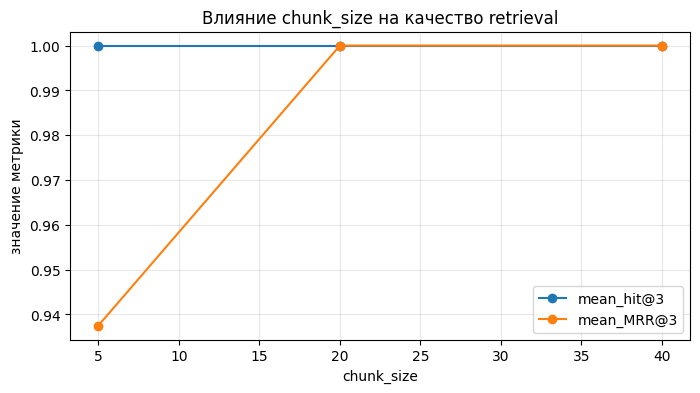

In [18]:
# Небольшая визуализация: как меняется качество при разных конфигурациях чанкинга.
# chunk_experiments_df отсортирован по качеству; для графика обязательно сортируем по chunk_size,
# иначе ось X будет в произвольном порядке и линии пересекутся.
plot_df = chunk_experiments_df.sort_values("chunk_size").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["chunk_size"], plot_df["mean_hit@3"], marker="o", label="mean_hit@3")
plt.plot(plot_df["chunk_size"], plot_df["mean_MRR@3"], marker="o", label="mean_MRR@3")
plt.xlabel("chunk_size")
plt.ylabel("значение метрики")
plt.title("Влияние chunk_size на качество retrieval")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Обновление базы знаний и переиндексация

In [19]:
new_documents = pd.concat([df.loc[[80]], df.loc[[158]]])
new_documents

,id,annotation,tags,text
80,doc_081,"Когда человек решает открыть свое дело, он ста...","['Начать бизнес', 'Планирование', 'Свое дело',...",## Оцените жизнеспособность идеи\n\nЧтобы поня...
158,doc_159,Николай не смог расплатиться в магазине: на ка...,"['Долги', 'Кредиты', 'Займы', 'Просрочки', 'За...",## В каких ситуациях приставы списывают деньги...


In [20]:
updated_documents = pd.concat([documents, new_documents], axis=0, ignore_index=True)

In [21]:
updated_documents

,id,annotation,tags,text
0,doc_001,Светлана из Казани дает частные уроки английск...,"['Начать бизнес', 'Самозанятые', 'Свое дело', ...",## Кто такой самозанятый?\n\nПо закону самозан...
1,doc_002,"Елене назначили социальное пособие на ребенка,...","['Защитить права', 'Банки', 'Банковская карта'...",Первым делом нужно попросить банк проверить ма...
2,doc_081,"Когда человек решает открыть свое дело, он ста...","['Начать бизнес', 'Планирование', 'Свое дело',...",## Оцените жизнеспособность идеи\n\nЧтобы поня...
3,doc_159,Николай не смог расплатиться в магазине: на ка...,"['Долги', 'Кредиты', 'Займы', 'Просрочки', 'За...",## В каких ситуациях приставы списывают деньги...


In [22]:
new_queries = [
    "В чем отличие самозанятости от ИП?",
    "Какие списания по кредиту можно вернуть?",
]

display(Markdown("### Как baseline-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

### Как baseline-база отвечает на новые запросы

**Запрос:** В чем отличие самозанятости от ИП?

,rank,score,doc_id,title,chunk_text
0,1,0.484401,doc_001,Светлана из Казани дает частные уроки английск...,найти новых клиентов. Компаниям выгоднее работ...
1,2,0.475647,doc_001,Светлана из Казани дает частные уроки английск...,вы самостоятельно заявите как профессиональный...
2,3,0.465007,doc_001,Светлана из Казани дает частные уроки английск...,действительно зарегистрированы как самозанятый...


**Запрос:** Какие списания по кредиту можно вернуть?

,rank,score,doc_id,title,chunk_text
0,1,0.620608,doc_002,"Елене назначили социальное пособие на ребенка,...","этом случае, зависит от типа списания. Средств..."
1,2,0.560131,doc_002,"Елене назначили социальное пособие на ребенка,...","Но какой бы ни была причина, по которой сняли ..."
2,3,0.537020,doc_002,"Елене назначили социальное пособие на ребенка,...",вернуть. Подать в банк заявление о возврате ре...


In [23]:
# Переиндексируем корпус уже с новыми документами.
updated_artifacts = build_retriever(
    updated_documents,
    chunk_size=30,
    overlap=10,
    device=DEVICE,
)

# Расширяем benchmark новыми запросами.
extended_benchmark_queries = benchmark_queries + [
    {
        "query_id": "q09",
        "query": "В чем отличие самозанятости от ИП?",
        "relevant_doc_ids": ["doc_081"],
    },
    {
        "query_id": "q10",
        "query": "Какие списания по кредиту можно вернуть?",
        "relevant_doc_ids": ["doc_159"],
    },
]

before_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=artifacts, top_k=3)
after_update_eval = evaluate_benchmark(extended_benchmark_queries, artifacts=updated_artifacts, top_k=3)

comparison_df = before_update_eval.merge(
    after_update_eval,
    on=["query_id", "query", "relevant_doc_ids"],
    suffixes=("_before", "_after"),
)

display(comparison_df)

summary_comparison_df = pd.DataFrame(
    {
        "metric": ["mean_hit@3", "mean_recall@3", "mean_MRR@3"],
        "before_update": [
            before_update_eval["hit@3"].mean(),
            before_update_eval["recall@3"].mean(),
            before_update_eval["MRR@3"].mean(),
        ],
        "after_update": [
            after_update_eval["hit@3"].mean(),
            after_update_eval["recall@3"].mean(),
            after_update_eval["MRR@3"].mean(),
        ],
    }
)
summary_comparison_df["delta"] = summary_comparison_df["after_update"] - summary_comparison_df["before_update"]
display(summary_comparison_df)

display(Markdown("### Как updated-база отвечает на новые запросы"))
for query in new_queries:
    display(Markdown(f"**Запрос:** {query}"))
    display(search_chunks(query, artifacts=updated_artifacts, top_k=3)[["rank", "score", "doc_id", "title", "chunk_text"]])

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2307.55it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,query_id,query,relevant_doc_ids,predicted_doc_ids_before,hit@3_before,recall@3_before,MRR@3_before,first_relevant_rank_before,predicted_doc_ids_after,hit@3_after,recall@3_after,MRR@3_after,first_relevant_rank_after
0,q01,Кто не может стать самозанятым?,doc_001,doc_001,1,1.0,1.0,1.0,"doc_001, doc_081",1,1.0,1.0,1
1,q02,Как и где платить подоходный налог?,doc_001,doc_001,1,1.0,1.0,1.0,"doc_081, doc_001",1,1.0,0.5,2
2,q03,Кто переводит часть зарплаты в Социальный фонд?,doc_001,doc_001,1,1.0,1.0,1.0,"doc_001, doc_159",1,1.0,1.0,1
3,q04,Можно ли вернуть деньги после списания?,doc_002,doc_002,1,1.0,1.0,1.0,"doc_159, doc_002",1,1.0,0.5,2
4,q05,Когда вернутся деньги?,doc_002,doc_002,1,1.0,1.0,1.0,"doc_002, doc_159",1,1.0,1.0,1
5,q06,Какие есть коды начислений?,doc_002,doc_002,1,1.0,1.0,1.0,doc_002,1,1.0,1.0,1
6,q07,Какие есть ставки для самозанятых?,doc_001,doc_001,1,1.0,1.0,1.0,doc_001,1,1.0,1.0,1
7,q08,"ФССП отказывается возвращать деньги, что делать?",doc_002,doc_002,1,1.0,1.0,1.0,"doc_002, doc_159",1,1.0,1.0,1
8,q09,В чем отличие самозанятости от ИП?,doc_081,doc_001,0,0.0,0.0,NaN,doc_081,1,1.0,1.0,1
9,q10,Какие списания по кредиту можно вернуть?,doc_159,doc_002,0,0.0,0.0,NaN,"doc_159, doc_002",1,1.0,1.0,1


,metric,before_update,after_update,delta
0,mean_hit@3,0.8,1.0,0.2
1,mean_recall@3,0.8,1.0,0.2
2,mean_MRR@3,0.8,0.9,0.1


### Как updated-база отвечает на новые запросы

**Запрос:** В чем отличие самозанятости от ИП?

,rank,score,doc_id,title,chunk_text
0,1,0.588337,doc_081,"Когда человек решает открыть свое дело, он ста...","отличие от самозанятых, ИП доступны кредиты на..."
1,2,0.528246,doc_081,"Когда человек решает открыть свое дело, он ста...","вырастет, придется регистрироваться в другом к..."
2,3,0.494979,doc_081,"Когда человек решает открыть свое дело, он ста...",ограниченной ответственностью — ООО). **1. Ста...


**Запрос:** Какие списания по кредиту можно вернуть?

,rank,score,doc_id,title,chunk_text
0,1,0.636787,doc_159,Николай не смог расплатиться в магазине: на ка...,"заказным письмом и дает несколько дней, чтобы ..."
1,2,0.636665,doc_159,Николай не смог расплатиться в магазине: на ка...,счет долга по кредиту на основании вашего согл...
2,3,0.620608,doc_002,"Елене назначили социальное пособие на ребенка,...","этом случае, зависит от типа списания. Средств..."


In [24]:
# Посмотрим, по каким запросам retrieval всё ещё может ошибаться.
analysis_rows = []

for row in extended_benchmark_queries:
    metrics = evaluate_query(
        query=row["query"],
        relevant_doc_ids=row["relevant_doc_ids"],
        artifacts=updated_artifacts,
        top_k=3,
    )
    analysis_rows.append(
        {
            "query_id": row["query_id"],
            "query": row["query"],
            "relevant_doc_ids": ", ".join(row["relevant_doc_ids"]),
            "predicted_doc_ids": ", ".join(metrics["predicted_doc_ids"]),
            "hit@3": metrics["hit"],
            "first_relevant_rank": metrics["first_relevant_rank"],
        }
    )

analysis_df = pd.DataFrame(analysis_rows)
failed_or_weak = analysis_df[
    (analysis_df["hit@3"] == 0) | (analysis_df["first_relevant_rank"].fillna(99) > 1)
].reset_index(drop=True)

display(failed_or_weak if len(failed_or_weak) > 0 else analysis_df.head(0))

if len(failed_or_weak) == 0:
    print("На этом маленьком benchmark все запросы нашли релевантный документ на первом месте.")
else:
    print("Запросы выше стоит разобрать вручную: возможно, проблема в формулировке запроса, чанкинге или составе корпуса.")

,query_id,query,relevant_doc_ids,predicted_doc_ids,hit@3,first_relevant_rank
0,q02,Как и где платить подоходный налог?,doc_001,"doc_081, doc_001",1,2
1,q04,Можно ли вернуть деньги после списания?,doc_002,"doc_159, doc_002",1,2


Запросы выше стоит разобрать вручную: возможно, проблема в формулировке запроса, чанкинге или составе корпуса.


## Mini-RAG

In [25]:
def build_context_from_retrieval(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    retrieved = search_chunks(query, artifacts=artifacts, top_k=top_k)
    context_blocks = []

    for _, row in retrieved.iterrows():
        block = (
            f"[Источник: {row['doc_id']} | score={row['score']:.4f}]\n"
            f"{row['chunk_text']}"
        )
        context_blocks.append(block)

    context = "\n\n".join(context_blocks)
    return context, retrieved

In [26]:
query = "Какие списания по кредиту можно вернуть?"
context, retrieved_df = build_context_from_retrieval(query, artifacts=artifacts, top_k=3)

display(Markdown(f"### Запрос: {query}"))
display(retrieved_df)
print(context)

### Запрос: Какие списания по кредиту можно вернуть?

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.620608,doc_002,"Елене назначили социальное пособие на ребенка,...",doc_002_chunk_13,"этом случае, зависит от типа списания. Средств..."
1,2,0.560131,doc_002,"Елене назначили социальное пособие на ребенка,...",doc_002_chunk_07,"Но какой бы ни была причина, по которой сняли ..."
2,3,0.537020,doc_002,"Елене назначили социальное пособие на ребенка,...",doc_002_chunk_08,вернуть. Подать в банк заявление о возврате ре...


[Источник: doc_002 | score=0.6206]
этом случае, зависит от типа списания. Средства, которые ушли в счет кредита, вернуть не получится. Если же банк списал деньги по требованию судебных приставов, придется самостоятельно обращаться к ним и

[Источник: doc_002 | score=0.5601]
Но какой бы ни была причина, по которой сняли деньги с правильно проставленной маркировкой, по закону вы вправе потребовать их вернуть. Подать в банк заявление о возврате регулярной социальной выплаты

[Источник: doc_002 | score=0.5370]
вернуть. Подать в банк заявление о возврате регулярной социальной выплаты можно в течение 14 дней с момента списания, разовой — в любое время. Деньги должны перечислить обратно не позднее трех


In [27]:
def split_into_sentences(text: str) -> List[str]:
    parts = re.split(r"(?<=[.!?])\s+", text.strip())
    return [p.strip() for p in parts if p.strip()]

def generate_answer_from_context(query: str, context: str, max_sentences: int = 2) -> str:
    # Убираем технические строки источников из ранжирования, но не из общего контекста.
    raw_lines = [line.strip() for line in context.splitlines() if line.strip()]
    content_lines = [line for line in raw_lines if not line.startswith("[Источник:")]

    sentence_pool = []
    for line in content_lines:
        sentence_pool.extend(split_into_sentences(line))

    sentence_pool = [s for s in sentence_pool if len(s.split()) >= 4]

    if not sentence_pool:
        return "Недостаточно контекста для построения ответа."

    vectorizer = TfidfVectorizer(ngram_range=(1, 2))
    matrix = vectorizer.fit_transform([query] + sentence_pool).toarray().astype(np.float32)

    query_vec = matrix[0]
    sentence_vecs = matrix[1:]

    query_norm = np.linalg.norm(query_vec) + 1e-12
    sent_norms = np.linalg.norm(sentence_vecs, axis=1) + 1e-12
    scores = (sentence_vecs @ query_vec) / (sent_norms * query_norm)

    ranked_idx = np.argsort(-scores)
    selected_sentences = []
    used_normalized = set()

    for idx in ranked_idx:
        sentence = sentence_pool[idx]
        normalized = sentence.lower().strip()
        if scores[idx] <= 0:
            continue
        if normalized in used_normalized:
            continue
        used_normalized.add(normalized)
        selected_sentences.append(sentence)
        if len(selected_sentences) >= max_sentences:
            break

    if not selected_sentences:
        return "В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа."

    return " ".join(selected_sentences)

In [28]:
answer_example = generate_answer_from_context(query, context)
print(answer_example)

Но какой бы ни была причина, по которой сняли деньги с правильно проставленной маркировкой, по закону вы вправе потребовать их вернуть. Подать в банк заявление о возврате регулярной социальной выплаты можно в течение 14 дней с момента списания, разовой — в любое время.


In [29]:
def mini_rag_answer(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_answer_sentences: int = 2,
) -> Dict[str, object]:
    context, retrieved = build_context_from_retrieval(query, artifacts=artifacts, top_k=top_k)
    answer = generate_answer_from_context(query, context=context, max_sentences=max_answer_sentences)

    return {
        "query": query,
        "answer": answer,
        "context": context,
        "sources": retrieved,
    }

In [30]:
rag_result = mini_rag_answer(
    "Какие налоги надо платить самозанятому?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Какие налоги надо платить самозанятому?

**Ответ:** режима НПД для вас начнут действовать другие налоги. В большинстве случаев придется платить стандартный налог на доходы физических лиц (НДФЛ).

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.749141,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_04,Сколько составляет налог на профессиональный д...
1,2,0.732734,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_80,налогообложения для ИП вы хотите обслуживаться...
2,3,0.716284,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_75,режима НПД для вас начнут действовать другие н...


In [31]:
rag_rows = []

In [32]:
rag_rows.append(
      {
          "question": "Какие налоги надо платить самозанятому?",
          "answer": rag_result['answer'],
          "retrieved_sources": rag_result["sources"],
      }
  )

In [33]:
rag_result = mini_rag_answer(
    "Какие есть коды платежей?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Какие есть коды платежей?

**Ответ:** В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.657695,doc_002,"Елене назначили социальное пособие на ребенка,...",doc_002_chunk_02,код дохода: код 2 для регулярных соцвыплат и к...
1,2,0.636809,doc_002,"Елене назначили социальное пособие на ребенка,...",doc_002_chunk_01,Первым делом нужно попросить банк проверить ма...
2,3,0.616688,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_46,перечислить в налоговую. НПД надо заплатить не...


In [34]:
rag_rows.append(
      {
          "question": "Какие есть коды платежей?",
          "answer": rag_result['answer'],
          "retrieved_sources": rag_result["sources"],
      }
  )

In [35]:
rag_result = mini_rag_answer(
    "Какие списания можно вернуть?",
    artifacts=artifacts,
    top_k=3,
)

display(Markdown(f"### Вопрос: {rag_result['query']}"))
display(Markdown(f"**Ответ:** {rag_result['answer']}"))
display(Markdown("**Источники:**"))
display(rag_result["sources"])

### Вопрос: Какие списания можно вернуть?

**Ответ:** В этом случае оспорить списание и вернуть социальную выплату не получится.

**Источники:**

,rank,score,doc_id,title,chunk_id,chunk_text
0,1,0.495852,doc_002,"Елене назначили социальное пособие на ребенка,...",doc_002_chunk_19,"то **деньги** **потеряют маркировку** и, как с..."
1,2,0.449788,doc_002,"Елене назначили социальное пособие на ребенка,...",doc_002_chunk_20,## Как избежать списаний в будущем? Чтобы сниз...
2,3,0.294365,doc_001,Светлана из Казани дает частные уроки английск...,doc_001_chunk_23,"товаров, которые произвел кто-то другой; * пос..."


In [36]:
rag_rows.append(
      {
          "question": "Какие списания можно вернуть?",
          "answer": rag_result['answer'],
          "retrieved_sources": rag_result["sources"],
      }
  )

Пара примеров выше оказалась неудачной:

- Вопрос: Какие списания можно вернуть?
- Ответ: В этом случае оспорить списание и вернуть социальную выплату не получится.

Подозреваю что здесь повлияло разделение чанков либо формировка ответа. Ответ на вопрос явно находится перед предложением, которое вывелось в качестве ответа.

- Вопрос: Какие есть коды платежей?
- Ответ: В найденном контексте нет достаточно релевантного фрагмента для уверенного ответа.

Хотя в одном из источников упоминаются некоторые коды платежей, что является ответом на вопрос. Но так как, видимо, совпадение по словам довольно маленькое, то и score маленький.

## Сохранение артефактов

In [37]:
rag_df = pd.DataFrame(rag_rows)

rag_df.to_csv(
    os.path.join(ARTIFACTS_DIR, "rag_examples.csv"),
    index=False
)

display(rag_df)

,question,answer,retrieved_sources
0,Какие налоги надо платить самозанятому?,режима НПД для вас начнут действовать другие н...,rank score doc_id ...
1,Какие есть коды платежей?,В найденном контексте нет достаточно релевантн...,rank score doc_id ...
2,Какие списания можно вернуть?,В этом случае оспорить списание и вернуть соци...,rank score doc_id ...


In [38]:
def build_retrieval_eval_csv(eval_df: pd.DataFrame, top_k: int = 3) -> pd.DataFrame:
    rows = []

    for _, row in eval_df.iterrows():
        rows.append(
            {
                "query": row["query"],
                "expected_source": row["relevant_doc_ids"],
                "retrieved_sources": row["predicted_doc_ids"],
                "hit_at_k": row[f"hit@{top_k}"],
                "rank_of_first_relevant": row["first_relevant_rank"],
            }
        )

    return pd.DataFrame(rows)


retrieval_eval_csv = build_retrieval_eval_csv(baseline_eval_k3, top_k=3)

retrieval_eval_csv.to_csv(
    os.path.join(ARTIFACTS_DIR, "retrieval_eval.csv"),
    index=False
)

display(retrieval_eval_csv.head())

,query,expected_source,retrieved_sources,hit_at_k,rank_of_first_relevant
0,Кто не может стать самозанятым?,doc_001,doc_001,1,1
1,Как и где платить подоходный налог?,doc_001,doc_001,1,1
2,Кто переводит часть зарплаты в Социальный фонд?,doc_001,doc_001,1,1
3,Можно ли вернуть деньги после списания?,doc_002,doc_002,1,1
4,Когда вернутся деньги?,doc_002,doc_002,1,1


In [39]:
def build_before_after_csv(before_df: pd.DataFrame, after_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    merged = before_df.merge(
        after_df,
        on=["query_id", "query", "relevant_doc_ids"],
        suffixes=("_before", "_after"),
    )

    for _, row in merged.iterrows():
        before_sources = row["predicted_doc_ids_before"]
        after_sources = row["predicted_doc_ids_after"]

        rows.append(
            {
                "query": row["query"],
                "before_retrieved_sources": before_sources,
                "after_retrieved_sources": after_sources,
                "changed": int(before_sources != after_sources),
            }
        )

    return pd.DataFrame(rows)


before_after_csv = build_before_after_csv(before_update_eval, after_update_eval)

before_after_csv.to_csv(
    os.path.join(ARTIFACTS_DIR, "retrieval_before_after_update.csv"),
    index=False
)

display(before_after_csv)

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Кто не может стать самозанятым?,doc_001,"doc_001, doc_081",1
1,Как и где платить подоходный налог?,doc_001,"doc_081, doc_001",1
2,Кто переводит часть зарплаты в Социальный фонд?,doc_001,"doc_001, doc_159",1
3,Можно ли вернуть деньги после списания?,doc_002,"doc_159, doc_002",1
4,Когда вернутся деньги?,doc_002,"doc_002, doc_159",1
5,Какие есть коды начислений?,doc_002,doc_002,0
6,Какие есть ставки для самозанятых?,doc_001,doc_001,0
7,"ФССП отказывается возвращать деньги, что делать?",doc_002,"doc_002, doc_159",1
8,В чем отличие самозанятости от ИП?,doc_001,doc_081,1
9,Какие списания по кредиту можно вернуть?,doc_002,"doc_159, doc_002",1
